In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scienceplots

torch.manual_seed(67)
np.random.seed(67)
sns.set_palette("husl")
# importing my preferred style
plt.style.use(['science', 'no-latex', 'grid'])
plt.rcParams.update({'font.size':20})
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams['axes.formatter.use_mathtext'] = True

In [10]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

print(f"Is CUDA supported by this system? {torch.cuda.is_available()}")
print(f"Current CUDA device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"CUDA version: {torch.version.cuda}")
torch.backends.cudnn.benchmark = True

Using cuda device
Is CUDA supported by this system? True
Current CUDA device name: NVIDIA GeForce RTX 3090
CUDA version: 13.0


In [11]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("cvdl/oxford-pets")

In [12]:
# reformat bounding box from width height to x_min, y_min, x_max, y_max
def reformat_bounding_box(example):
    boxes = example['objects']['bbox']
    reformatted_boxes = []
    for box in boxes:
        x_min = box[0]
        y_min = box[1]
        x_max = box[0] + box[2]
        y_max = box[1] + box[3]
        reformatted_boxes.append([x_min, y_min, x_max, y_max])
    example['objects']['bbox'] = reformatted_boxes
    return example

# ds = ds.map(reformat_bounding_box)

In [13]:
# print some info about the dataset
print(ds)

# print a sample from the dataset
print(ds['train'][0])

DatasetDict({
    train: Dataset({
        features: ['img', 'msk', 'bbox', 'class', 'category'],
        num_rows: 2567
    })
    valid: Dataset({
        features: ['img', 'msk', 'bbox', 'class', 'category'],
        num_rows: 701
    })
    test: Dataset({
        features: ['img', 'msk', 'bbox', 'class', 'category'],
        num_rows: 403
    })
})
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x297 at 0x1EA2FCE6190>, 'msk': <PIL.PngImagePlugin.PngImageFile image mode=L size=300x297 at 0x1EA2FCE62C0>, 'bbox': [39, 51, 156, 179], 'class': 0, 'category': 0}


In [ ]:
# use numeric classes directly (no name mapping)
label_key = "category" if "category" in ds["train"].column_names else "class"
labels_in_train = ds["train"][label_key]
unique_labels = sorted(set(labels_in_train))
class_names = [str(x) for x in unique_labels]
class_to_idx = {int(x): i for i, x in enumerate(unique_labels)}

def _get_image_size(img):
    if hasattr(img, "size"):
        w, h = img.size
        return w, h
    if isinstance(img, np.ndarray):
        h, w = img.shape[:2]
        return w, h
    if torch.is_tensor(img):
        h, w = img.shape[-2], img.shape[-1]
        return int(w), int(h)
    return None, None

def add_objects(example):
    image = example.get("img", example.get("image"))
    bbox = example.get("bbox", None)
    label = example.get(label_key, 0)
    if isinstance(label, (list, tuple)):
        label = label[0] if len(label) > 0 else 0
    label = int(label)
    label_idx = class_to_idx.get(label, 0)
    # ensure list-of-boxes format
    if bbox is None:
        boxes = [[0, 0, 0, 0]]
    elif isinstance(bbox, (list, tuple)) and len(bbox) == 4 and not isinstance(bbox[0], (list, tuple)):
        boxes = [list(bbox)]
    else:
        boxes = [list(b) for b in bbox]
    example["image"] = image
    example["objects"] = {"bbox": boxes, "category": [label_idx]}
    return example

ds = ds.map(add_objects)

Map:  39%|███▉      | 999/2567 [00:22<03:57,  6.60 examples/s] 

In [8]:
# show an image with bounding boxes and labels
def show_image_with_boxes(example):
    image = example.get('image', example.get('img'))
    boxes = example['objects']['bbox']
    labels = example['objects']['category']
    
    # handle raw, normalized, or 0-255 images
    image_to_show = image
    if isinstance(image, np.ndarray):
        image_to_show = image.copy()
        if image_to_show.max() > 1.0 and image_to_show.min() >= 0:
            image_to_show = image_to_show / 255.0
        if (image_to_show.min() < 0 or image_to_show.max() > 1.0) and 'mean' in globals() and 'std' in globals():
            image_to_show = (image_to_show * std) + mean
        image_to_show = np.clip(image_to_show, 0, 1)

    plt.imshow(image_to_show)
    ax = plt.gca()
    
    for box, label in zip(boxes, labels):
        if torch.is_tensor(label):
            label_idx = int(label.item())
        else:
            label_idx = int(label)
        label_name = str(label_idx)
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x_min, y_min, label_name, fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))
    
    plt.axis('off')
    plt.show()

# show a sample image from the training set
show_image_with_boxes(ds['train'][0])

KeyError: 'image'

In [36]:
# check out dataset
print(f"Train dataset size: {len(ds['train'])}")
print(f"Val dataset size: {len(ds['validation'])}" if "validation" in ds else f"Val dataset size: N/A")
print(f"Classes: {sorted(set(ds['train'][label_key]))}")
example = ds['train'][0]
print(f"Sample example keys: {example.keys()}")
print(f"Sample example: {example}")

Train dataset size: 5717
Val dataset size: 5823
Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
Sample example keys: dict_keys(['image_id', 'image', 'width', 'height', 'objects', 'major_class'])
Sample example: {'image_id': 0, 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x442 at 0x1AB7872F230>, 'width': 500, 'height': 442, 'objects': {'id': [0, 1], 'area': [139194, 16113], 'bbox': [[53.0, 87.0, 471.0, 420.0], [158.0, 44.0, 289.0, 167.0]], 'category': [12, 14]}, 'major_class': 12}


In [37]:
# downsize images and bounding boxes
from PIL import Image

def downsize_image(example, size=(128, 128)):
    image = example.get('image', example.get('img'))
    if hasattr(image, "size"):
        w, h = image.size
    elif isinstance(image, np.ndarray):
        h, w = image.shape[:2]
        image = Image.fromarray(image)
    elif torch.is_tensor(image):
        h, w = image.shape[-2], image.shape[-1]
        image = Image.fromarray(image.permute(1, 2, 0).cpu().numpy().astype(np.uint8))
    else:
        return example
    if "objects" in example and "bbox" in example["objects"]:
        example['objects']['bbox'] = [
            [box[0] * size[0] / w,
             box[1] * size[1] / h,
             box[2] * size[0] / w,
             box[3] * size[1] / h] for box in example['objects']['bbox']
        ]
    image = image.resize(size)
    example['image'] = image
    return example
ds = ds.map(downsize_image)

In [38]:
# find mean and std of the dataset
def compute_mean_std(dataset):
    mean = np.zeros(3)
    std = np.zeros(3)
    n = len(dataset)
    for example in dataset:
        image = np.array(example['image']) / 255.0
        mean += image.mean(axis=(0, 1))
        std += image.std(axis=(0, 1))
    mean /= n
    std /= n
    return mean, std

mean, std = compute_mean_std(ds['train'])

In [39]:
# normalize dataset
def normalize_image(example, mean, std):
    image = np.array(example['image']) / 255.0
    image = (image - mean) / std
    example['image'] = image
    return example

ds = ds.map(lambda x: normalize_image(x, mean, std))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0108655088780565..2.598577007251188].


11
11
11


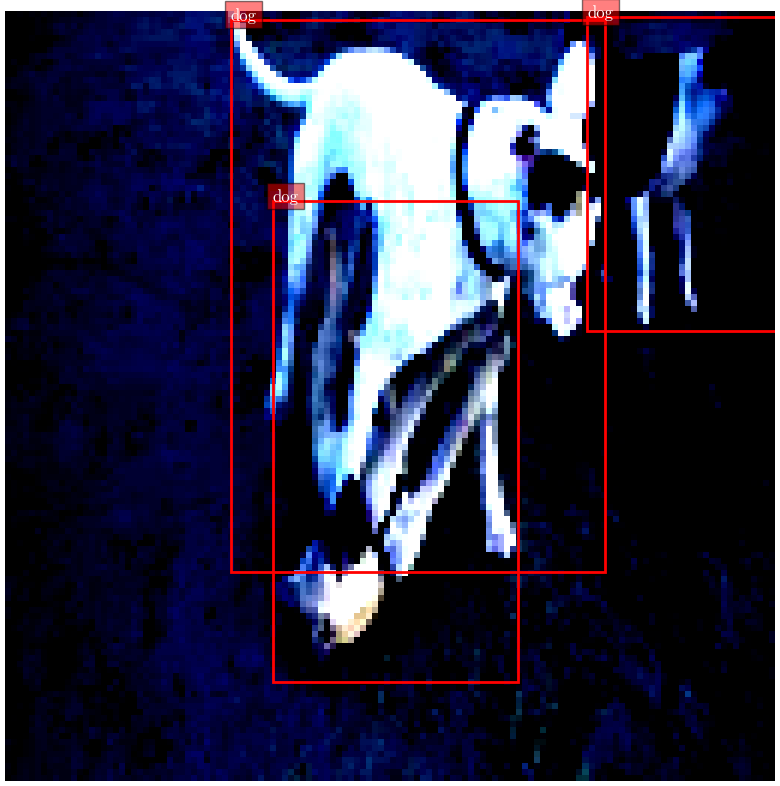

In [40]:
# see a sample normalized image
show_image_with_boxes(ds['train'][2])

In [41]:
# convert dataset to PyTorch tensors

def to_tensor(example):
    image = example['image']

    if isinstance(image, torch.Tensor):
        # If tensor is already CHW, keep it; if HWC, transpose
        if image.ndim == 3 and image.shape[0] in (1, 3):
            chw_image = image
        elif image.ndim == 3 and image.shape[-1] in (1, 3):
            chw_image = image.permute(2, 0, 1)
        else:
            chw_image = torch.tensor(np.array(image).transpose(2, 0, 1), dtype=torch.float32)
    else:
        np_image = np.array(image)
        if np_image.ndim == 3 and np_image.shape[-1] in (1, 3):
            chw_image = torch.tensor(np_image.transpose(2, 0, 1), dtype=torch.float32)
        else:
            chw_image = torch.tensor(np_image, dtype=torch.float32)

    example['image'] = chw_image
    example['objects']['bbox'] = torch.tensor(example['objects']['bbox'], dtype=torch.float32)
    example['objects']['category'] = torch.tensor(example['objects']['category'], dtype=torch.long)
    return example

ds = ds.map(to_tensor)

In [42]:
# augment dataset on-the-fly to avoid RAM blow-up
from torchvision.transforms import v2

def _augment_single(example):
    image = example["image"]
    objects = example["objects"]
    boxes = objects["bbox"]
    categories = objects["category"]

    # ensure tensors
    if not torch.is_tensor(image):
        np_image = np.array(image)
        if np_image.ndim == 3 and np_image.shape[-1] in (1, 3):
            image = torch.tensor(np_image.transpose(2, 0, 1), dtype=torch.float32)
        else:
            image = torch.tensor(np_image, dtype=torch.float32)
    if not torch.is_tensor(boxes):
        boxes = torch.tensor(boxes, dtype=torch.float32)
    if not torch.is_tensor(categories):
        categories = torch.tensor(categories, dtype=torch.long)

    # horizontal flip
    if torch.rand(1).item() < 0.5:
        image = torch.flip(image, dims=[2])
        width = image.shape[2]
        x_min = width - boxes[:, 2]
        x_max = width - boxes[:, 0]
        boxes = torch.stack([x_min, boxes[:, 1], x_max, boxes[:, 3]], dim=1)

    # vertical flip
    if torch.rand(1).item() < 0.5:
        image = torch.flip(image, dims=[1])
        height = image.shape[1]
        y_min = height - boxes[:, 3]
        y_max = height - boxes[:, 1]
        boxes = torch.stack([boxes[:, 0], y_min, boxes[:, 2], y_max], dim=1)

    # color jitter
    if torch.rand(1).item() < 0.5:
        color_jitter = v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        image = color_jitter(image)

    example["image"] = image
    example["objects"] = {"bbox": boxes, "category": categories}
    return example

def apply_random_augment(example):
    # handle batched inputs from datasets formatter
    if isinstance(example.get("image"), list):
        images = []
        objects_list = []
        for img, obj in zip(example["image"], example["objects"]):
            ex = {"image": img, "objects": obj}
            ex = _augment_single(ex)
            images.append(ex["image"])
            objects_list.append(ex["objects"])
        example["image"] = images
        example["objects"] = objects_list
        return example
    return _augment_single(example)

# apply augmentation only during training, without duplicating the dataset in memory
# not augmenting for now
train_ds = ds["train"]
# train_ds = ds["train"].with_transform(apply_random_augment)

In [43]:
# parameters
batch_size = 512
num_epochs = 20
learning_rate = 1e-2
num_workers = 0
pin_memory = device == "cuda"
# persistent_workers = num_workers > 0

In [44]:
from torch.utils.data import DataLoader

class VOCDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset):
        self.ds = hf_dataset

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        example = self.ds[idx]
        image = example["image"]
        boxes = example["objects"]["bbox"]
        labels = example["objects"]["category"]

        # ensure tensor image in CHW
        if not torch.is_tensor(image):
            np_image = np.array(image)
            if np_image.ndim == 3 and np_image.shape[-1] in (1, 3):
                image = torch.tensor(np_image.transpose(2, 0, 1), dtype=torch.float32)
            else:
                image = torch.tensor(np_image, dtype=torch.float32)
        elif image.ndim == 3 and image.shape[-1] in (1, 3):
            image = image.permute(2, 0, 1).float()
        else:
            image = image.float()

        if not torch.is_tensor(boxes):
            boxes = torch.tensor(boxes, dtype=torch.float32)
        else:
            boxes = boxes.float()
        if not torch.is_tensor(labels):
            labels = torch.tensor(labels, dtype=torch.long)
        else:
            labels = labels.long()

        # keep only valid boxes
        if boxes.numel() > 0:
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[keep]
            labels = labels[keep]

        # normalize boxes to [0, 1] using image size
        h, w = image.shape[1], image.shape[2]
        if boxes.numel() > 0:
            scale = torch.tensor([w, h, w, h], dtype=torch.float32)
            boxes = boxes / scale
            boxes = boxes.clamp(0.0, 1.0)

        return image, labels, boxes


def collate_fn(batch):
    flat_images = []
    flat_labels = []
    flat_boxes = []
    flat_valids = []

    for image, labels, boxes in batch:
        if boxes.numel() > 0:
            for i in range(boxes.shape[0]):
                flat_images.append(image)
                flat_labels.append(labels[i])
                flat_boxes.append(boxes[i])
                flat_valids.append(torch.tensor(1.0))
        else:
            flat_images.append(image)
            flat_labels.append(torch.tensor(0, dtype=torch.long))
            flat_boxes.append(torch.zeros(4, dtype=torch.float32))
            flat_valids.append(torch.tensor(0.0))

    images = torch.stack(flat_images, dim=0)
    labels = torch.stack(flat_labels, dim=0)
    boxes = torch.stack(flat_boxes, dim=0)
    valids = torch.stack(flat_valids, dim=0)
    return images, labels, boxes, valids

# DataLoaders
split_names = list(ds.keys())
val_split = "validation" if "validation" in split_names else ("test" if "test" in split_names else "train")
test_split = "test" if "test" in split_names else val_split

train_dataset = VOCDataset(train_ds)
valid_dataset = VOCDataset(ds[val_split])
test_dataset = VOCDataset(ds[test_split])

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory
 )

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory
 )

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory
 )

In [45]:
# CNN implementation (custom detector)
import torch.nn as nn
import torch.nn.functional as F

class MyCNNDetector(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super(MyCNNDetector, self).__init__()
        self.__conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /2
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /4
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),  # /8
            nn.Conv2d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.4),
            nn.MaxPool2d(kernel_size=2, stride=2)   # /16
        )
        self.__pool = nn.AdaptiveAvgPool2d((4, 4))
        self.__flatten = nn.Flatten()
        self.__shared = nn.Sequential(
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.__cls_head = nn.Linear(256, num_classes)
        self.__bbox_head = nn.Linear(256, 4)

    def forward(self, x):
        features = self.__conv(x)
        pooled = self.__pool(features)
        flat = self.__flatten(pooled)
        shared = self.__shared(flat)
        class_logits = self.__cls_head(shared)
        bbox_pred = torch.sigmoid(self.__bbox_head(shared))
        return class_logits, bbox_pred


In [46]:
model = MyCNNDetector(num_classes=len(class_names), dropout_rate=0.5).to(device)
criterion_classification = nn.CrossEntropyLoss()
criterion_bbox = nn.SmoothL1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0005)


In [47]:
def train_one_epoch(model, dataloader, optimizer, device, cls_weight=1.0, box_weight=1.0):
    model.train()
    running_total = 0.0
    running_cls = 0.0
    running_box = 0.0

    for images, labels, boxes, valids in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        boxes = boxes.to(device)
        valids = valids.to(device)

        class_logits, bbox_pred = model(images)

        # classification loss (only on valid samples)
        if valids.sum() > 0:
            cls_loss = criterion_classification(class_logits[valids == 1], labels[valids == 1])
            box_loss = criterion_bbox(bbox_pred[valids == 1], boxes[valids == 1])
        else:
            cls_loss = torch.tensor(0.0, device=device)
            box_loss = torch.tensor(0.0, device=device)

        loss = cls_weight * cls_loss + box_weight * box_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_total += loss.item()
        running_cls += cls_loss.item()
        running_box += box_loss.item()

    epoch_loss = running_total / max(1, len(dataloader))
    cls_loss = running_cls / max(1, len(dataloader))
    box_loss = running_box / max(1, len(dataloader))
    return epoch_loss, cls_loss, box_loss


def validate_one_epoch(model, dataloader, device, cls_weight=1.0, box_weight=1.0):
    model.eval()
    running_total = 0.0
    running_cls = 0.0
    running_box = 0.0

    with torch.no_grad():
        for images, labels, boxes, valids in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            boxes = boxes.to(device)
            valids = valids.to(device)

            class_logits, bbox_pred = model(images)

            if valids.sum() > 0:
                cls_loss = criterion_classification(class_logits[valids == 1], labels[valids == 1])
                box_loss = criterion_bbox(bbox_pred[valids == 1], boxes[valids == 1])
            else:
                cls_loss = torch.tensor(0.0, device=device)
                box_loss = torch.tensor(0.0, device=device)

            loss = cls_weight * cls_loss + box_weight * box_loss

            running_total += loss.item()
            running_cls += cls_loss.item()
            running_box += box_loss.item()

    epoch_loss = running_total / max(1, len(dataloader))
    cls_loss = running_cls / max(1, len(dataloader))
    box_loss = running_box / max(1, len(dataloader))
    return epoch_loss, cls_loss, box_loss


def train_model(model, train_loader, valid_loader, optimizer, device, num_epochs, patience=10):
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_cls, train_box = train_one_epoch(
            model, train_loader, optimizer, device, cls_weight=1.0, box_weight=1.0
        )
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train: total={train_loss:.4f}, cls={train_cls:.4f}, box={train_box:.4f}"
        )

        val_loss, val_cls, val_box = validate_one_epoch(
            model, valid_loader, device, cls_weight=1.0, box_weight=1.0
        )
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Val: total={val_loss:.4f}, cls={val_cls:.4f}, box={val_box:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break


In [48]:
train_model(model, train_dataloader, valid_dataloader, optimizer, device, num_epochs=10)

Epoch 1/10 | Train: total=2.7658, cls=2.7214, box=0.0444
Epoch 1/10 | Val: total=2.8498, cls=2.8093, box=0.0405
Epoch 2/10 | Train: total=2.6070, cls=2.5747, box=0.0323
Epoch 2/10 | Val: total=2.6676, cls=2.6334, box=0.0343


KeyboardInterrupt: 

In [49]:
# test the model
test_loss, test_cls, test_box = validate_one_epoch(
    model, test_dataloader, device, cls_weight=1.0, box_weight=1.0
)
print(
    f"Test: total={test_loss:.4f}, cls={test_cls:.4f}, box={test_box:.4f}"
)

Test: total=2.6368, cls=2.6026, box=0.0342


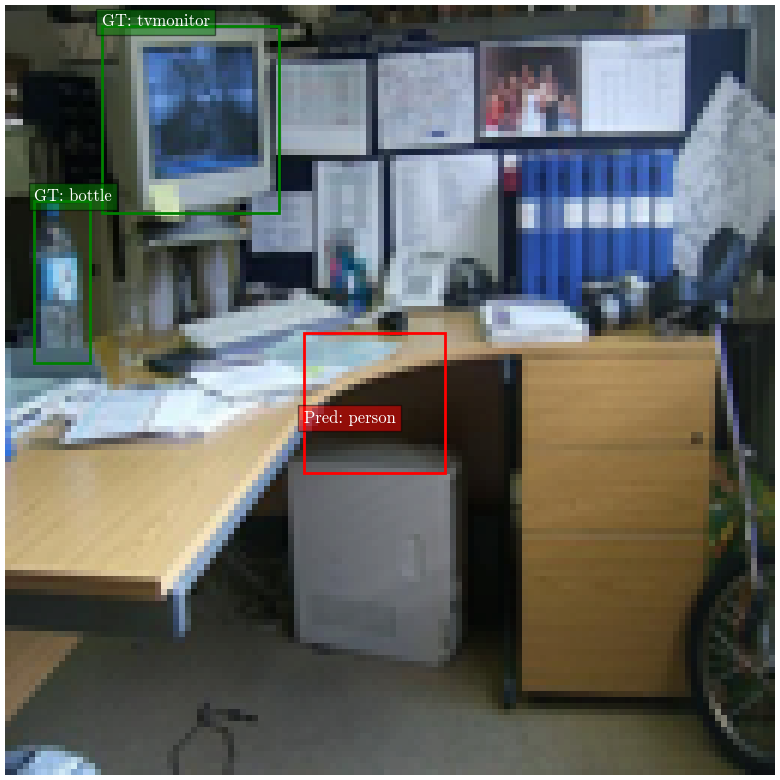

In [62]:
# show a random sample prediction
import random
idx = random.randint(0, len(test_dataset) - 1)
image, labels, boxes = test_dataset[idx]
model.eval()
with torch.no_grad():
    image_in = image.unsqueeze(0).to(device)
    class_logits, bbox_pred = model(image_in)
    predicted_label = torch.argmax(class_logits, dim=1).item()
    predicted_box = bbox_pred.squeeze(0).cpu().numpy()

# visualize prediction
image_np = image.numpy().transpose(1, 2, 0)
# denormalize for display (dataset is normalized with mean/std)
image_np = (image_np * std) + mean
image_np = np.clip(image_np, 0, 1)
plt.imshow(image_np)
ax = plt.gca()

# ground truth boxes
if boxes.numel() > 0:
    for i in range(boxes.shape[0]):
        x_min, y_min, x_max, y_max = boxes[i].numpy()
        x_min *= image_np.shape[1]
        x_max *= image_np.shape[1]
        y_min *= image_np.shape[0]
        y_max *= image_np.shape[0]
        width = x_max - x_min
        height = y_max - y_min
        rect = plt.Rectangle((x_min, y_min), width, height, fill=False, color='green', linewidth=2)
        ax.add_patch(rect)
        ax.text(
            x_min,
            y_min,
            f"GT: {class_names[labels[i].item()]}",
            fontsize=12,
            color='white',
            bbox=dict(facecolor='green', alpha=0.5)
        )

# predicted box
x_min, y_min, x_max, y_max = predicted_box
x_min *= image_np.shape[1]
x_max *= image_np.shape[1]
y_min *= image_np.shape[0]
y_max *= image_np.shape[0]
width = x_max - x_min
height = y_max - y_min
rect = plt.Rectangle((x_min, y_min), width, height, fill=False, color='red', linewidth=2)
ax.add_patch(rect)
ax.text(x_min, y_min + 15, f"Pred: {class_names[predicted_label]}", fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))
plt.axis('off')
plt.show()